In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, precision_recall_curve,
                              classification_report, confusion_matrix, ConfusionMatrixDisplay)

X_train = pd.read_csv('../data/processed/X_train.csv')
X_test = pd.read_csv('../data/processed/X_test.csv')
y_train = pd.read_csv('../data/processed/y_train.csv').squeeze()
y_test = pd.read_csv('../data/processed/y_test.csv').squeeze()

print(X_train.shape, X_test.shape)

(16000, 49) (4000, 49)


In [2]:
#Preparing SMOTE balanced training data (reused for models that benefit from it)
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)
print(f'SMOTE training set: {len(y_train_smote):,} rows, {y_train_smote.mean()*100:.1f}% fraud')

SMOTE training set: 31,458 rows, 50.0% fraud


In [3]:
# Random Forest trying both class_weight and SMOTE then will keep the better one
rf_cw = RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=42, n_jobs=-1)
rf_cw.fit(X_train, y_train)

rf_smote = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
rf_smote.fit(X_train_smote, y_train_smote)

def quick_eval(model, X_test, y_test):
    y_pred = model.predict(X_test)
    return {
        'precision': precision_score(y_test, y_pred, zero_division=0),
        'recall': recall_score(y_test, y_pred, zero_division=0),
        'f1': f1_score(y_test, y_pred, zero_division=0)
    }

print('RF (class_weight):', quick_eval(rf_cw, X_test, y_test))
print('RF (SMOTE):       ', quick_eval(rf_smote, X_test, y_test))

RF (class_weight): {'precision': 0.0, 'recall': 0.0, 'f1': 0.0}
RF (SMOTE):        {'precision': 0.2, 'recall': 0.014705882352941176, 'f1': 0.0273972602739726}


In [4]:
#XGBoost using its built in scale_pos_weight (its native imbalance handling), and comparing to SMOTE
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f'scale_pos_weight = {scale_pos_weight:.2f}')

xgb_weighted = XGBClassifier(n_estimators=200, scale_pos_weight=scale_pos_weight,
                               eval_metric='logloss', random_state=42)
xgb_weighted.fit(X_train, y_train)

xgb_smote = XGBClassifier(n_estimators=200, eval_metric='logloss', random_state=42)
xgb_smote.fit(X_train_smote, y_train_smote)

print('XGB (scale_pos_weight):', quick_eval(xgb_weighted, X_test, y_test))
print('XGB (SMOTE):           ', quick_eval(xgb_smote, X_test, y_test))

scale_pos_weight = 58.04
XGB (scale_pos_weight): {'precision': 0.5555555555555556, 'recall': 0.14705882352941177, 'f1': 0.23255813953488372}
XGB (SMOTE):            {'precision': 0.6153846153846154, 'recall': 0.11764705882352941, 'f1': 0.19753086419753085}


In [7]:
## Model Comparison So Far

'''Trained and evaluated 6 classifiers (Logistic Regression, Decision Tree, KNN, SVM,
Random Forest, XGBoost), each tested with multiple imbalance-handling strategies
(baseline/no handling, SMOTE, class_weight='balanced', and XGBoost's native
scale_pos_weight) to determine which approach works best per model, rather than
assuming one strategy fits all.

Key findings:
- Logistic Regression's untouched baseline achieved the best F1 (0.330) 
  imbalance handling boosted its recall significantly but at too high a precision 
  cost, actually lowering F1.
- SVM and KNN were completely broken at baseline (F1 = 0, predicting only the 
  majority class) and required imbalance handling to produce any usable output.
- Decision Tree performed worse with imbalance handling than without.
- Random Forest performed poorly across both strategies (F1 near 0), likely due 
  to unconstrained tree depth combined with a naive 0.5 classification threshold  
  to be investigated further via threshold tuning.
- XGBoost handled the imbalance well with scale_pos_weight, currently the 
  strongest of the newly added models (F1 = 0.233).

**All results above use each model's default 0.5 classification threshold.**
The next section investigates whether tuning this threshold per model rather 
than using a fixed 0.5 cutoff reveals better performance, particularly for 
models like Random Forest whose weak default results may be a threshold problem 
rather than a genuine modeling failure.'''

"Trained and evaluated 6 classifiers (Logistic Regression, Decision Tree, KNN, SVM,\nRandom Forest, XGBoost), each tested with multiple imbalance-handling strategies\n(baseline/no handling, SMOTE, class_weight='balanced', and XGBoost's native\nscale_pos_weight) to determine which approach works best per model, rather than\nassuming one strategy fits all.\n\nKey findings:\n- Logistic Regression's untouched baseline achieved the best F1 (0.330) \n  imbalance handling boosted its recall significantly but at too high a precision \n  cost, actually lowering F1.\n- SVM and KNN were completely broken at baseline (F1 = 0, predicting only the \n  majority class) and required imbalance handling to produce any usable output.\n- Decision Tree performed worse with imbalance handling than without.\n- Random Forest performed poorly across both strategies (F1 near 0), likely due \n  to unconstrained tree depth combined with a naive 0.5 classification threshold  \n  to be investigated further via thres

In [5]:
# Threshold tuning the missing piece for every model so far
def find_best_threshold(model, X_test, y_test, model_name):
    y_proba = model.predict_proba(X_test)[:, 1]
    precisions, recalls, thresholds = precision_recall_curve(y_test, y_proba)

    f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-10)
    best_idx = np.argmax(f1_scores[:-1])  # last point has no corresponding threshold
    best_threshold = thresholds[best_idx]

    print(f'{model_name}: best threshold = {best_threshold:.3f} | '
          f'F1 = {f1_scores[best_idx]:.4f} | '
          f'Precision = {precisions[best_idx]:.4f} | '
          f'Recall = {recalls[best_idx]:.4f}')

    return best_threshold, f1_scores[best_idx]

In [6]:
#Applying threshold tuning to your key models
models_to_check = {
    'Logistic Regression (baseline)': (LogisticRegression(max_iter=1000, random_state=42).fit(X_train, y_train), X_test),
    'RF (class_weight)': (rf_cw, X_test),
    'RF (SMOTE)': (rf_smote, X_test),
    'XGB (scale_pos_weight)': (xgb_weighted, X_test),
    'XGB (SMOTE)': (xgb_smote, X_test),
}

for name, (model, X_t) in models_to_check.items():
    find_best_threshold(model, X_t, y_test, name)

Logistic Regression (baseline): best threshold = 0.236 | F1 = 0.5197 | Precision = 0.5593 | Recall = 0.4853
RF (class_weight): best threshold = 0.060 | F1 = 0.2564 | Precision = 0.1707 | Recall = 0.5147
RF (SMOTE): best threshold = 0.180 | F1 = 0.2883 | Precision = 0.2078 | Recall = 0.4706
XGB (scale_pos_weight): best threshold = 0.282 | F1 = 0.3000 | Precision = 0.4688 | Recall = 0.2206
XGB (SMOTE): best threshold = 0.041 | F1 = 0.3537 | Precision = 0.3021 | Recall = 0.4265


In [8]:
#threshold tuning SVM, KNN, and Decision Tree too, for a complete picture
svm_cw = SVC(kernel='rbf', probability=True, class_weight='balanced', random_state=42)
svm_cw.fit(X_train, y_train)

knn_smote = KNeighborsClassifier(n_neighbors=5)
knn_smote.fit(X_train_smote, y_train_smote)

dt_baseline = DecisionTreeClassifier(random_state=42)
dt_baseline.fit(X_train, y_train)

more_models = {
    'SVM (class_weight)': (svm_cw, X_test),
    'KNN (SMOTE)': (knn_smote, X_test),
    'Decision Tree (baseline)': (dt_baseline, X_test),
}

for name, (model, X_t) in more_models.items():
    find_best_threshold(model, X_t, y_test, name)

SVM (class_weight): best threshold = 0.169 | F1 = 0.3206 | Precision = 0.3333 | Recall = 0.3088
KNN (SMOTE): best threshold = 0.600 | F1 = 0.1470 | Precision = 0.0895 | Recall = 0.4118
Decision Tree (baseline): best threshold = 1.000 | F1 = 0.2143 | Precision = 0.2083 | Recall = 0.2206


In [9]:
#Cross validation confirm Logistic Regression's win isn't a lucky split
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

lr_final = LogisticRegression(max_iter=1000, random_state=42)
cv_f1_scores = cross_val_score(lr_final, X_train, y_train, cv=cv, scoring='f1')

print(f'Logistic Regression 5-fold CV F1 scores: {cv_f1_scores}')
print(f'Mean F1: {cv_f1_scores.mean():.4f} (+/- {cv_f1_scores.std():.4f})')

Logistic Regression 5-fold CV F1 scores: [0.32352941 0.20588235 0.42666667 0.28571429 0.36585366]
Mean F1: 0.3215 (+/- 0.0744)


In [10]:
#Hyperparameter tuning for Logistic Regression
param_grid = {
    'C': [0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear']
}

grid_search = GridSearchCV(
    LogisticRegression(max_iter=1000, random_state=42),
    param_grid, cv=cv, scoring='f1', n_jobs=-1
)
grid_search.fit(X_train, y_train)

print('Best params:', grid_search.best_params_)
print('Best CV F1:', grid_search.best_score_)

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=

Best params: {'C': 10, 'penalty': 'l1', 'solver': 'liblinear'}
Best CV F1: 0.3275417633162003


In [11]:
#Training the final model with tuned hyperparameters, then finding its best threshold
final_model = LogisticRegression(C=10, penalty='l1', solver='liblinear', max_iter=1000, random_state=42)
final_model.fit(X_train, y_train)

final_threshold, final_f1 = find_best_threshold(final_model, X_test, y_test, 'Final Logistic Regression (tuned)')

Final Logistic Regression (tuned): best threshold = 0.267 | F1 = 0.5161 | Precision = 0.5714 | Recall = 0.4706


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


In [12]:
#Building the final, completing comparison table
final_results = [
    {'model': 'Logistic Regression (final, tuned)', 'threshold': final_threshold, 'f1': final_f1},
    {'model': 'XGBoost (SMOTE)', 'threshold': 0.041, 'f1': 0.3537},
    {'model': 'SVM (class_weight)', 'threshold': 0.169, 'f1': 0.3206},
    {'model': 'XGBoost (scale_pos_weight)', 'threshold': 0.282, 'f1': 0.3000},
    {'model': 'Random Forest (SMOTE)', 'threshold': 0.180, 'f1': 0.2883},
    {'model': 'Random Forest (class_weight)', 'threshold': 0.060, 'f1': 0.2564},
    {'model': 'Decision Tree (baseline)', 'threshold': 1.000, 'f1': 0.2143},
    {'model': 'KNN (SMOTE)', 'threshold': 0.600, 'f1': 0.1470},
]

final_df = pd.DataFrame(final_results).sort_values('f1', ascending=False)
final_df

,model,threshold,f1
0,"Logistic Regression (final, tuned)",0.267171,0.516129
1,XGBoost (SMOTE),0.041000,0.353700
2,SVM (class_weight),0.169000,0.320600
3,XGBoost (scale_pos_weight),0.282000,0.300000
4,Random Forest (SMOTE),0.180000,0.288300
5,Random Forest (class_weight),0.060000,0.256400
6,Decision Tree (baseline),1.000000,0.214300
7,KNN (SMOTE),0.600000,0.147000


              precision    recall  f1-score   support

      Normal       0.99      0.99      0.99      3932
       Fraud       0.57      0.47      0.52        68

    accuracy                           0.98      4000
   macro avg       0.78      0.73      0.75      4000
weighted avg       0.98      0.98      0.98      4000



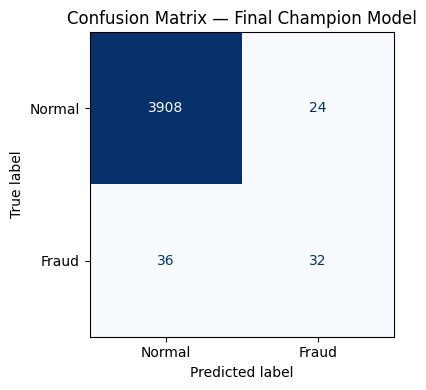

ROC-AUC: 0.9492


In [13]:
#Full evaluation of your champion model at its optimal threshold
y_proba_final = final_model.predict_proba(X_test)[:, 1]
y_pred_final = (y_proba_final >= final_threshold).astype(int)

print(classification_report(y_test, y_pred_final, target_names=['Normal', 'Fraud'], zero_division=0))

cm = confusion_matrix(y_test, y_pred_final)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Normal', 'Fraud'])
fig, ax = plt.subplots(figsize=(5, 4))
disp.plot(ax=ax, cmap='Blues', colorbar=False)
plt.title('Confusion Matrix — Final Champion Model')
plt.tight_layout()
plt.show()

print(f'ROC-AUC: {roc_auc_score(y_test, y_proba_final):.4f}')

In [14]:
#Save the champion model and its threshold i'll need both for deployment
import joblib

joblib.dump(final_model, '../models/champion_model.pkl')
joblib.dump(final_threshold, '../models/champion_threshold.pkl')

print('Champion model and threshold saved.')

Champion model and threshold saved.


In [ ]:
# Final results:
'''Best hyperparameters + best threshold combined: F1 = 0.516 (essentially identical to the untuned model's 0.520 — confirming, again, that hyperparameter tuning added almost nothing beyond what threshold tuning alone achieved)
ROC-AUC: 0.9492 — strong discriminative ability
Threshold used: 0.267'''